###Μηχανική Μάθηση
####1η ατομική εργασία
ΣΗΜΜΥ- ΕΜΠ -Ακ. Έτος 2024-25



Ονοματεπώνυμο φοιτητή: Δημήτριος Θανόγιαννης

Α.Μ.: 03121902

### 1. Εισαγωγή συνόλου δεδομένων

Tο σύνολο δεδομένων για το training-validation μπορείτε να το κατεβάσετε από [εδώ](https://drive.google.com/file/d/1ro8ff5KZwErgkxIvb3D5ykp2l5nV75Yj/view?usp=sharing).


1.α. Φορτώστε το σύνολο δεδομένων "train-val.csv"  στο notebook σας.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
from google.colab import files

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest,chi2

from sklearn.model_selection import train_test_split

np.random.seed(42)

%matplotlib inline

uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

Saving train-val.csv to train-val.csv


### 2. Διερευνητική ανάλυση δεδομένων -Exploratory Data Analysis (EDA)
Χρησιμοποιήστε code cells  με τις κατάλληλες τεχνικές EDA για την κατανόηση του συνόλου δεδομένων και text cells για επεξήγηση των αποτελεσμάτων.

Χρησιμοποιώντας τις κατάλληλες μεθόδους παρουσιάστε με χρήση κώδικα πληροφορίες για τα εξής:

2α. το πλήθος των δειγμάτων και των χαρακτηριστικών του συνόλου δεδομένων,

2β. το είδος των χαρακτηριστικών του συνόλου δεδομένων,  

2γ. τις ετικέτες των χαρακτηριστικών,

2δ. το πλήθος των κατηγοριών,

2ε. πόσα δείγματα ανήκουν σε κάθε κατηγορία,

2στ. τη συσχέτιση μεταξύ των δεδομένων,

2ζ. οποιαδήποτε άλλη πληροφορία πιστεύετε ότι είναι χρήσιμη για την κατανόηση του συνόλου δεδομένων.

In [2]:
df.head()

,ID,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,3423,2016-03-04,Tuggeranong,14.4,32.2,11.0,NaN,NaN,NE,22.0,...,81.0,32.0,1021.6,1018.0,NaN,NaN,18.4,31.2,1,0
1,6095,2013-06-23,GoldCoast,11.0,21.5,0.0,NaN,NaN,S,43.0,...,64.0,58.0,1024.1,1021.2,NaN,NaN,17.1,20.2,0,0
2,403,2009-07-05,Cobar,8.3,14.7,0.0,2.4,7.4,SSW,24.0,...,79.0,55.0,1021.8,1019.7,7.0,6.0,10.6,14.0,0,0
3,333,2014-10-12,BadgerysCreek,8.8,32.2,0.0,NaN,NaN,ENE,37.0,...,65.0,18.0,1017.5,1011.7,NaN,NaN,17.7,30.9,0,0
4,2085,2012-07-04,Sydney,7.2,16.2,0.0,3.6,6.4,NaN,NaN,...,55.0,43.0,1024.6,1025.1,3.0,7.0,9.6,15.9,0,1


In [3]:
df.info() #πληροφορίες για το όνομα των χαρακτηριστικών, το πλήθος κάθε χαρακτηριστικού και ο τύπος δεδομένων κάθε χαρακτηριστικού

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7262 entries, 0 to 7261
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             7262 non-null   int64  
 1   Date           7262 non-null   object 
 2   Location       7262 non-null   object 
 3   MinTemp        7237 non-null   float64
 4   MaxTemp        7251 non-null   float64
 5   Rainfall       7262 non-null   float64
 6   Evaporation    4223 non-null   float64
 7   Sunshine       3817 non-null   float64
 8   WindGustDir    6787 non-null   object 
 9   WindGustSpeed  6789 non-null   float64
 10  WindDir9am     6692 non-null   object 
 11  WindDir3pm     7049 non-null   object 
 12  WindSpeed9am   7207 non-null   float64
 13  WindSpeed3pm   7128 non-null   float64
 14  Humidity9am    7185 non-null   float64
 15  Humidity3pm    7094 non-null   float64
 16  Pressure9am    6576 non-null   float64
 17  Pressure3pm    6575 non-null   float64
 18  Cloud9am

In [4]:
df.describe() #στατιστικές πληροφορίες για τα χαρακτηριστικά

,ID,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
count,7262.000000,7237.000000,7251.000000,7262.000000,4223.000000,3817.000000,6789.000000,7207.000000,7128.000000,7185.000000,7094.000000,6576.000000,6575.000000,4592.000000,4443.000000,7228.000000,7142.000000,7262.000000,7262.000000
mean,4849.619113,10.638345,21.524562,2.302782,4.699005,7.356930,39.160701,13.674622,18.227273,70.242171,52.359459,1018.909367,1016.469262,4.368467,4.489534,15.426204,20.081686,0.228863,0.225695
std,2787.027799,5.994250,6.482395,8.027407,3.761805,3.539593,13.846248,8.918759,8.858489,18.807468,20.012168,7.061870,6.988741,2.909982,2.714390,6.079540,6.367390,0.420130,0.418068
min,2.000000,-7.600000,-3.700000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,2.000000,1.000000,990.800000,989.900000,0.000000,0.000000,-5.200000,-4.100000,0.000000,0.000000
25%,2441.500000,6.400000,16.900000,0.000000,2.200000,4.900000,30.000000,7.000000,11.000000,58.000000,38.000000,1014.300000,1011.800000,1.000000,2.000000,11.200000,15.600000,0.000000,0.000000
50%,4857.000000,10.300000,20.800000,0.000000,4.000000,8.200000,37.000000,13.000000,17.000000,71.000000,53.000000,1019.000000,1016.600000,5.000000,5.000000,14.900000,19.300000,0.000000,0.000000
75%,7245.750000,14.500000,25.800000,0.800000,6.400000,10.200000,46.000000,19.000000,24.000000,85.000000,66.000000,1023.600000,1021.200000,7.000000,7.000000,19.300000,24.200000,0.000000,0.000000
max,9683.000000,28.100000,42.800000,174.600000,50.800000,13.600000,104.000000,65.000000,83.000000,100.000000,100.000000,1040.200000,1036.700000,8.000000,9.000000,36.500000,41.700000,1.000000,1.000000


In [5]:
df.describe(include = 'object') #συμπερίληψη των χαρακτηριστικών με μορφότυπο δεδομένων object, που δεν εμφανίζονται στον προηγούμενο πίνακα

,Date,Location,WindGustDir,WindDir9am,WindDir3pm
count,7262,7262,6787,6692,7049
unique,2268,49,16,16,16
top,2010-06-01,Brisbane,W,N,W
freq,10,184,546,611,554


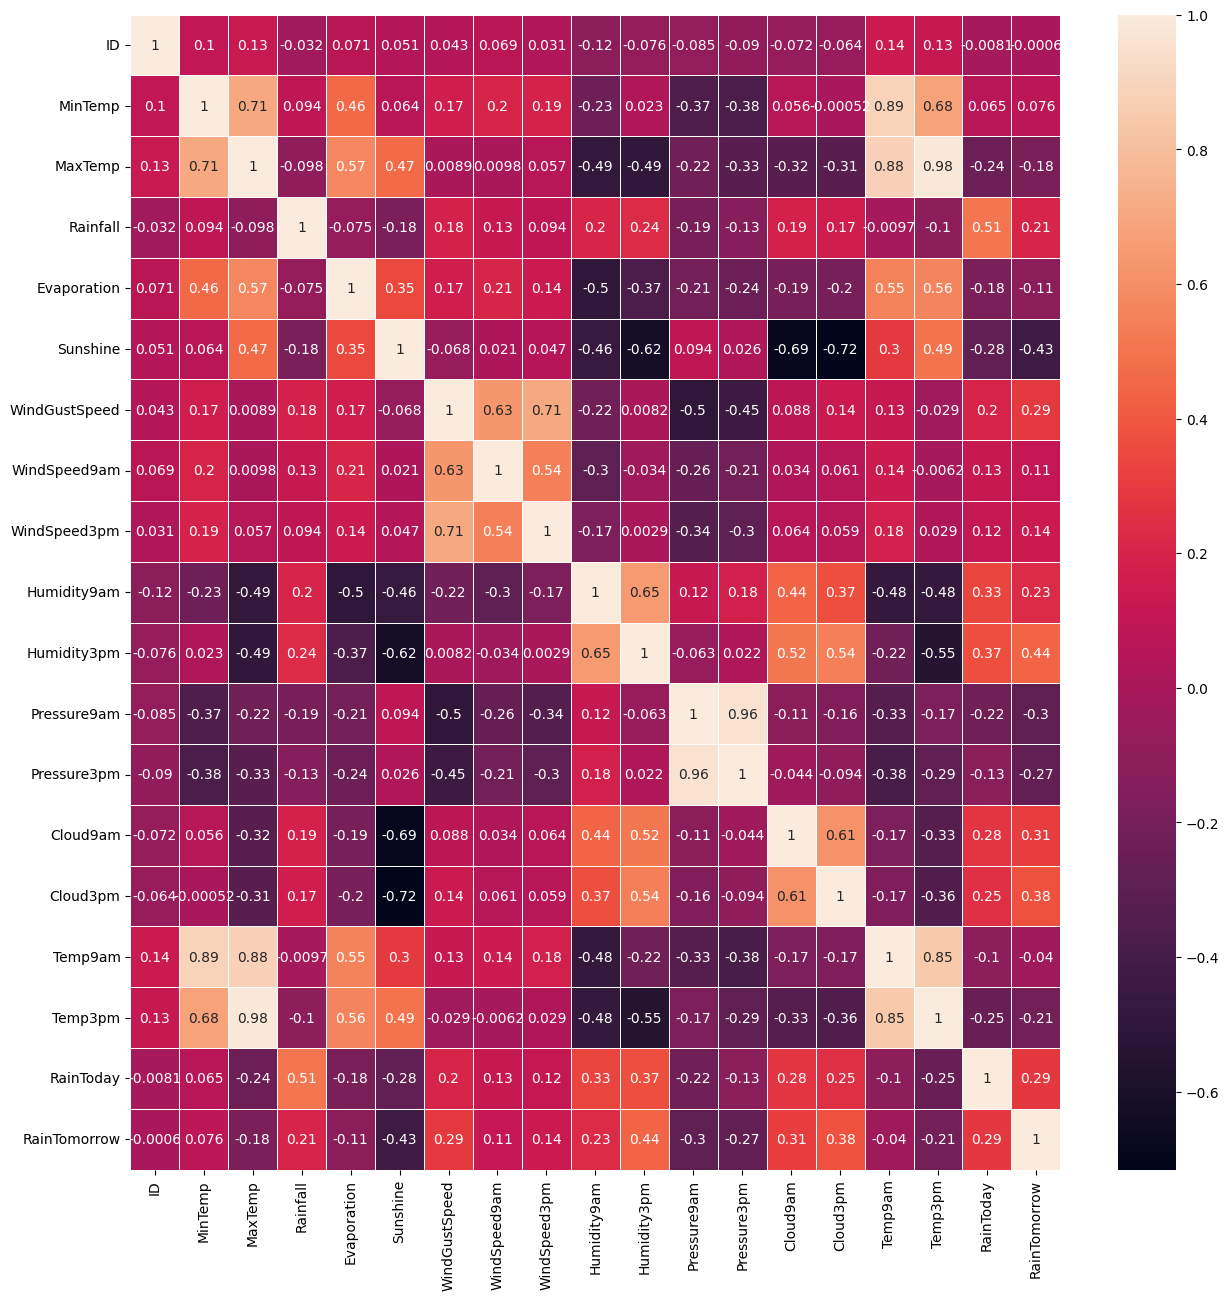

In [6]:
corr_matrix = df.select_dtypes(include=[np.number]).corr() #πίνακας συσχέτισης χαρακτηριστικών, βοηθάει στην κατανόηση των σχέσεων μεταξύ των χαρακτηριστικών. Εάν δύο χαρακτηριστικά έχουν υψηλή συσχέτιση, μπορεί να περιέχουν πλεονάζουσα πληροφορία, κάτι που μπορεί να επηρεάσει τη διαδικασία ανάλυσης ή μοντελοποίησης.

plt.figure(figsize=(15, 15))
sn.heatmap(corr_matrix, linewidths=0.5, annot=True)
plt.show()


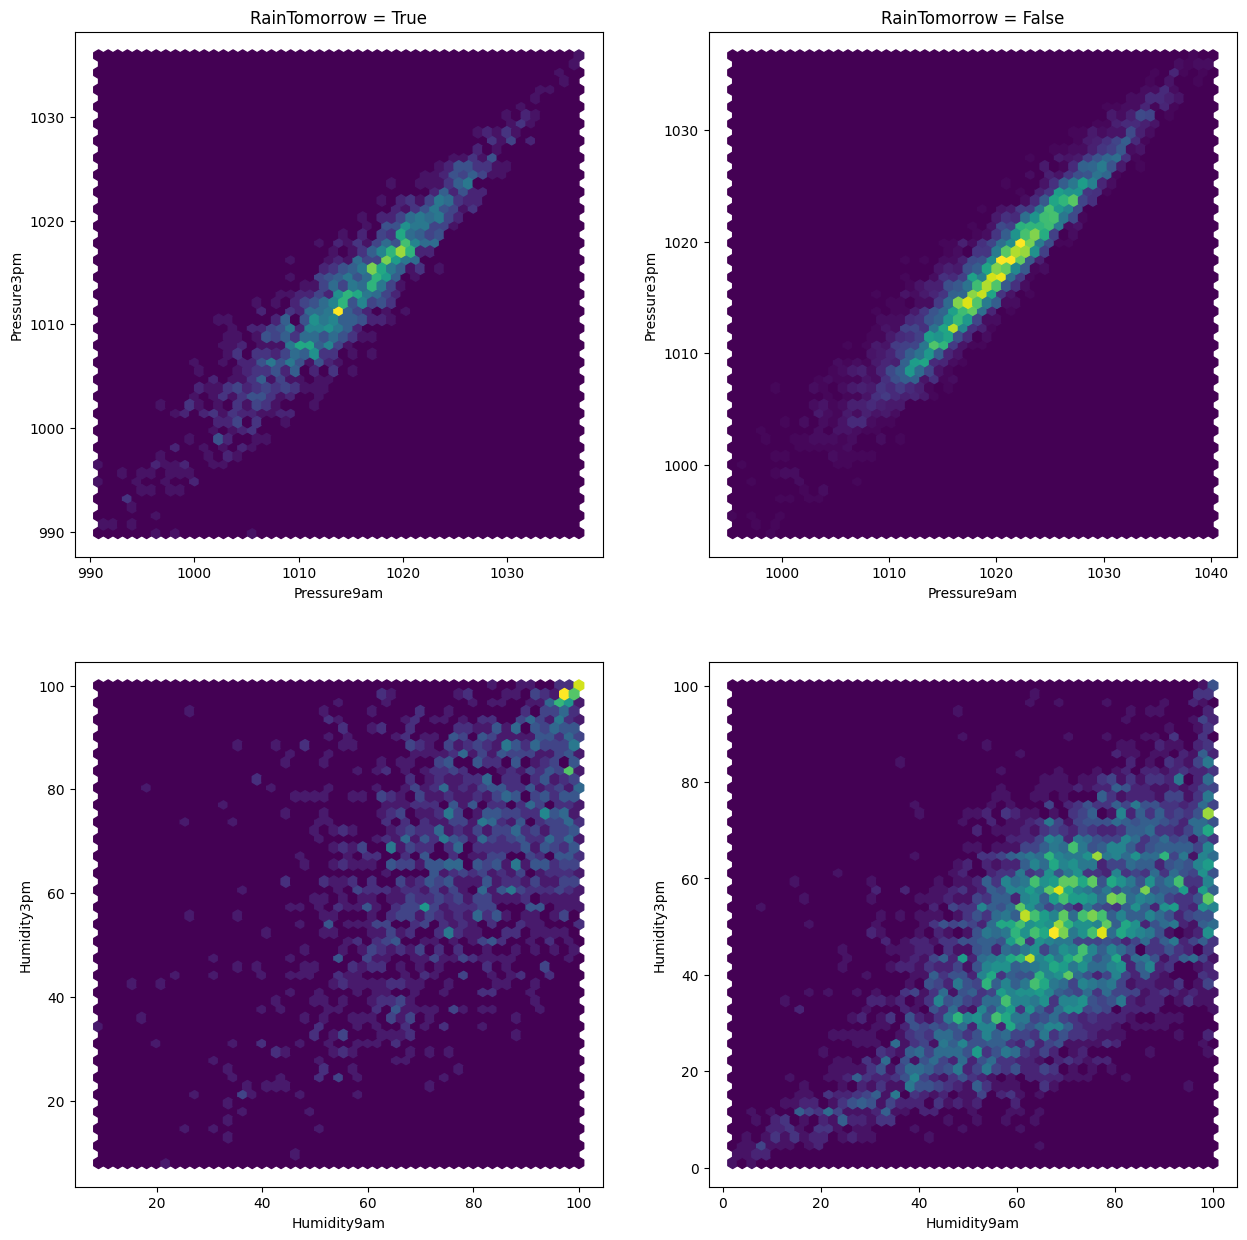

In [7]:
#η επιλογή των χαρακτηριστικών προς απεικόνιση έγινε με βάση το γεγονός ότι η πίεση έχει τη μεγαλύτερη αρνητική και η υγρασία τη μεγαλύτερη θετική συσχέτιση
#θέλουμε να δούμε για ποιές τιμές πίεσης και υγρασίας μέσα στη μέρα αυξάνεται η πιθανότητα αυριανής βροχής.

df_rain_true = df[df["RainTomorrow"] == 1]
df_rain_false = df[df["RainTomorrow"] == 0]

fig, axs = plt.subplots(2, 2)
fig.set_size_inches(15, 15)
axs[0,0].set_title("RainTomorrow = True")
axs[0,1].set_title("RainTomorrow = False")

axs[0,0].hexbin(df_rain_true['Pressure9am'],df_rain_true['Pressure3pm'],gridsize=50)
axs[0,0].set_xlabel("Pressure9am")
axs[0,0].set_ylabel("Pressure3pm")
axs[0,1].hexbin(df_rain_false['Pressure9am'],df_rain_false['Pressure3pm'],gridsize=50)
axs[0,1].set_xlabel("Pressure9am")
axs[0,1].set_ylabel("Pressure3pm")

axs[1,0].hexbin(df_rain_true['Humidity9am'],df_rain_true['Humidity3pm'],gridsize=50)
axs[1,0].set_xlabel("Humidity9am")
axs[1,0].set_ylabel("Humidity3pm")
axs[1,1].hexbin(df_rain_false['Humidity9am'],df_rain_false['Humidity3pm'],gridsize=50)
axs[1,1].set_xlabel("Humidity9am")
axs[1,1].set_ylabel("Humidity3pm")

plt.show()

 ⚠️ Κατά την προεπεξεργασία του συνόλου δεδομένων (τόσο του train-val όσο και του test) **MHN ΑΦΑΙΡΕΣΕΤΕ ΤΗΝ ΣΤΗΛΗ ID**  διότι χρειάζεται για τον διαγωνισμό kaggle.

### 3. Προεπεξεργασία συνόλου δεδομένων
💡`Χρησιμοποιήστε το Column Transformer για τη δημιουργία και την εφαρμογή χωριστών μετασχηματιστών για αριθμητικά και κατηγορικά δεδομένα.`




3.α.  Θα χρησιμοποιήσετε όλα τα χαρακτηριστικά του συνόλου δεδομένων για την εκπαίδευση των ταξινομητών ή θα επιλέξετε κάποια από αυτά;  Θα κάνετε κάποια συνένωση κάποιων χαρακτηριστικών για δημιουργία νέων χαρακτηριστικών για το μοντέλο σας;


Από τη στήλη των ημερομηνιών, κρατάμε μόνο το μήνα, αφού αυτός κυρίως σχετίζεται με την πιθανότητα βροχόπτωσης. Επίσης, τις τιμές της πίεσης, της ταχύτητας του ανέμου και της θερμοκρασίας του μεσημεριού τις ενώνουμε σε μία. Η ελάχιστη θερμοκρασιά και η θερμοκρασία του πρωινού σχετίζονται ελάχιστα με την αυριανή βροχόπτωση, οπότε απορρίπτονται.

Επιπλέον, απορρίπτεται η στήλη εξάτμησης, αφού απουσιάζει σε πολλά δείγματα(42%) και δεν παρουσιάζει υψηλή συσχέτιση με την βροχόπτωση. Πολλές τιμές λείπουν και από τις στήλες για τα σύννεφα και την ηλιοφάνεια, ωστόσο θα κρατήσουμε αυτές τις στήλες γιατί επηρεάζουν σημαντικά την πιθανότητα βροχόπτωσης.

Για τις κατηγορικές τιμές εκτός από την ημερομηνία, θα κρατήσω μόνο την επιρροή που έχουν στην πιθανότητα βροχόπτωσης. Έτσι, φτιάχνουμε μια μεταβλητή για τις πόλεις η οποία κρατά την πιθανότητα βροχόπτωσης στην κάθε πόλη. Για τις κατευθύνσεις του ανέμου, ενώνουμε την πληροφορία σε μια μεταβλητή, που εκτιμά την πιθανότητα βροχόπτωσης δεδομένων των 3 κατευθύνσεων.

Την αριθμητική μεταβλητή ID την κρατάμε γιατί χρειάζεται για το διαγωνισμό στο kaggle.

Καταλήγουμε έτσι σε 15 αριθμητικές μεταβλητές, τις οποίες θα χρησιμοποιήσουμε στο μοντέλο. Τις κανονικοποιούμε και γεμίζουμε τις άδειες τιμές με το μέσο όρο.

3.β. Υπάρχουν απουσιάζουσες τιμές; Γράψτε κατάλληλο κώδικα ώστε να χειριστείτε αυτές τις τιμές.

In [8]:
df.isnull().sum()

,0
ID,0
Date,0
Location,0
MinTemp,25
MaxTemp,11
Rainfall,0
Evaporation,3039
Sunshine,3445
WindGustDir,475
WindGustSpeed,473


3.γ. Γράψτε κώδικα για την κατάλληλη μετατροπή των κατηγορικών μεταβλητών ώστε να μπορούν να τους διαχειριστούν οι ταξινομητές που θα χρησιμοποιήσετε.

In [9]:
df['Pressure'] = df['Pressure9am'] + df['Pressure3pm'] #ενοποίηση διπλών τιμών σε μία

df['WindSpeed'] = df['WindSpeed9am'] + df['WindSpeed3pm']

df['Temp'] = df['MaxTemp'] + df['Temp3pm']

df['Date'] = pd.to_datetime(df['Date'], errors='coerce') #από την ημερομηνία κρτάμε μόνο το μήνα
df['Month'] = df['Date'].dt.month.fillna(0).astype(int)

mylist = df['WindGustDir'].unique() #ένωση πληροφορίας κατεύθυνσης ανέμου σε μία μεταβλητή και υπολογισμός πιθανότητας βροχόπτωσης δεδομένων των 3 κατευθύνσεων
rain_by_wind9 = {}
rain_by_wind3 = {}
rain_by_windg = {}

for dir in mylist:
    wind9 = df.loc[df['WindDir9am'] == dir, 'RainTomorrow'].sum() / len(df[df['WindDir9am'] == dir])
    wind3 = df.loc[df['WindDir3pm'] == dir, 'RainTomorrow'].sum() / len(df[df['WindDir3pm'] == dir])
    windg = df.loc[df['WindGustDir'] == dir, 'RainTomorrow'].sum() / len(df[df['WindGustDir'] == dir])
    rain_by_wind9[dir] = wind9
    rain_by_wind3[dir] = wind3
    rain_by_windg[dir] = windg

df['RainyWind'] = df.apply(lambda row: rain_by_wind9.get(row["WindDir9am"], 0) *
                                         rain_by_wind3.get(row["WindDir3pm"], 0) *
                                         rain_by_windg.get(row["WindGustDir"], 0), axis=1)

mylist = df['Location'].unique() #υπολογισμός πιθανότητας βροχόπτωσης σε κάθε πόλη
rain_by_city = {}

for city in mylist:
    city_data = df[df['Location'] == city]
    if len(city_data) > 0:
        rain_by_city[city] = city_data['RainTomorrow'].sum() / len(city_data)
    else:
        rain_by_city[city] = 0

df['RainyCity'] = df['Location'].map(rain_by_city)

df.info()

<ipython-input-9-e71bed8bffa2>:16: RuntimeWarning: invalid value encountered in scalar divide
  wind9 = df.loc[df['WindDir9am'] == dir, 'RainTomorrow'].sum() / len(df[df['WindDir9am'] == dir])
<ipython-input-9-e71bed8bffa2>:17: RuntimeWarning: invalid value encountered in scalar divide
  wind3 = df.loc[df['WindDir3pm'] == dir, 'RainTomorrow'].sum() / len(df[df['WindDir3pm'] == dir])
<ipython-input-9-e71bed8bffa2>:18: RuntimeWarning: invalid value encountered in scalar divide
  windg = df.loc[df['WindGustDir'] == dir, 'RainTomorrow'].sum() / len(df[df['WindGustDir'] == dir])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7262 entries, 0 to 7261
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ID             7262 non-null   int64         
 1   Date           7262 non-null   datetime64[ns]
 2   Location       7262 non-null   object        
 3   MinTemp        7237 non-null   float64       
 4   MaxTemp        7251 non-null   float64       
 5   Rainfall       7262 non-null   float64       
 6   Evaporation    4223 non-null   float64       
 7   Sunshine       3817 non-null   float64       
 8   WindGustDir    6787 non-null   object        
 9   WindGustSpeed  6789 non-null   float64       
 10  WindDir9am     6692 non-null   object        
 11  WindDir3pm     7049 non-null   object        
 12  WindSpeed9am   7207 non-null   float64       
 13  WindSpeed3pm   7128 non-null   float64       
 14  Humidity9am    7185 non-null   float64       
 15  Humidity3pm    7094 n

3.δ. Γράψτε κώδικα για την κλιμάκωση των χαρακτηριστικών, αν την θεωρείτε απαραίτητη

In [83]:
#παρακάτω

3.ε. Εκτελέστε όλα τα προηγούμενα βήμα προεκπαίδευσης (χρήση μετασχηματιστών) ώστε να είναι "καθαρό" το αρχικό σύνολο για να χρησιμοποιηθεί για την εκπαίδευση των ταξινομητών.

In [11]:
df3 = df.drop(['Date', 'Location', 'Evaporation', 'RainTomorrow', 'MinTemp', 'MaxTemp', 'Pressure9am', 'Pressure3pm',\
               'Temp9am', 'Temp3pm', 'WindDir3pm', 'WindDir9am', 'WindGustDir', 'WindSpeed9am', 'WindSpeed3pm'], axis=1) #κρατάμε τα 14 χαρακτηριστικά με την περισσότερη πληροφορία και το ID
df3.info()

numeric_features = list(df3.select_dtypes('number'))
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), #στις κενές τιμές βάζουμε το μέσο όρο των υπόλοιπων τιμών
    ('scaler', StandardScaler())]) #κανονικοποίηση των δεδομένων για να έχουν μέση τιμή 0 και τυπική απόκλιση 1

categorical_features = list(df3.select_dtypes('object'))
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), #στις κενές τιμές βάζουμε αυτό που εμφανίζεται συχνότερα
    ('scaler', OneHotEncoder(handle_unknown='ignore'))])  #μετατρέπουμε τα κατηγορικά δεδομένα σε αριθμητικά δεδομένα

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7262 entries, 0 to 7261
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             7262 non-null   int64  
 1   Rainfall       7262 non-null   float64
 2   Sunshine       3817 non-null   float64
 3   WindGustSpeed  6789 non-null   float64
 4   Humidity9am    7185 non-null   float64
 5   Humidity3pm    7094 non-null   float64
 6   Cloud9am       4592 non-null   float64
 7   Cloud3pm       4443 non-null   float64
 8   RainToday      7262 non-null   int64  
 9   Pressure       6570 non-null   float64
 10  WindSpeed      7118 non-null   float64
 11  Temp           7137 non-null   float64
 12  Month          7262 non-null   int64  
 13  RainyWind      6318 non-null   float64
 14  RainyCity      7262 non-null   float64
dtypes: float64(12), int64(3)
memory usage: 851.1 KB


3.στ. Αφού έχετε "καθαρίσει" το αρχικό σύνολο εκπαίδευσης, γράψτε τον κατάλληλο κώδικα ώστε από το αρχικό σύνολο εκπαίδευσης να δημιουργήσετε τα σύνολα Χ και y.

💡 `Η στήλη 'RainTomorrow' είναι η τιμή που θέλουμε να προβλέψει ο ταξινομητής μας.`



In [12]:
X = df3
y = df['RainTomorrow']

3.ζ. Διαχωρίστε το σύνολο δεδομένων σε σύνολο εκπαίδευσης (train set) και σε σύνολο επικύρωσης (validation set) (ο διαχωρισμός να είναι train set 70% και validation set 30%).


In [13]:
X_train, X_tst, y_train, y_tst = train_test_split(X, y, test_size=0.3)

### 4. Εκπαίδευση μοντέλου με default τιμές στις παραμέτρους των ταξινομητών

Θα εκπαιδεύσουμε τους ακόλουθους ταξινομητές με το σύνολο εκπαίδευσης των δεδομένων μας:
1. Naive Bayes
2. KNeighborsClassifier
3. LogisticRegression
4. MLP με ένα κρυφό επίπεδο
5. SVC
6. Decision Tree
7. Random Forest


 4.α. Εκπαιδεύστε (fit)  και τους  7 ταξινομητές που προαναφέρθηκαν (εμφανίστε τα δείγματα από το train set μαζί με την ετικέτα τους στην είσοδο του κάθε ταξινομητή), χρησιμοποιώντας τις default τιμές για όλες τις παραμέτρους τους.

In [14]:
from sklearn.metrics import f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

classifier = []
classifier.append(GaussianNB())
classifier.append(KNeighborsClassifier())
classifier.append(LogisticRegression())
classifier.append(MLPClassifier())
classifier.append(SVC())
classifier.append(DecisionTreeClassifier())
classifier.append(RandomForestClassifier())

L = len(classifier)

classifiers = ["Naive Bayes", "K-Nearest Neighbours", "Logistic Regression", "MLP Classifier", "SVC", "Decision Tree", "Random Forest"]

model = []
for cl in classifier:
    model.append(Pipeline(steps=[('preprocessor', preprocessor), ('classifier', cl)]))

for i in range(L):
    model[i].fit(X_train, y_train)
    print(f"{classifiers[i]}: Model trained.")

Naive Bayes: Model trained.
K-Nearest Neighbours: Model trained.
Logistic Regression: Model trained.


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Classifier: Model trained.
SVC: Model trained.
Decision Tree: Model trained.
Random Forest: Model trained.


4.β. Εφαρμόστε στα εκπαιδευμένα μοντέλα από το validation set μόνο τα δείγματα χωρίς την ετικέτα τους (predict).


In [15]:
y_pred = []

for i in range(L):
    y_pred.append(model[i].predict(X_tst))
    print(f"{classifiers[i]}: Predictions completed.")

Naive Bayes: Predictions completed.
K-Nearest Neighbours: Predictions completed.
Logistic Regression: Predictions completed.
MLP Classifier: Predictions completed.
SVC: Predictions completed.
Decision Tree: Predictions completed.
Random Forest: Predictions completed.



4.γ. Συγκρίνετε την έξοδο του κάθε μοντέλου σε σχέση με τις αντίστοιχες ετικέτες του validation set και αξιολογήστε την επιδοσή τους χρησιμοποιώντας το F1 score.


In [16]:
f1_scr = []

for i in range(L):
    score = f1_score(y_tst, y_pred[i])
    f1_scr.append(score)
    print(f"{classifiers[i]}: F1 Score = {score}")

Naive Bayes: F1 Score = 0.5809617271835132
K-Nearest Neighbours: F1 Score = 0.5343137254901961
Logistic Regression: F1 Score = 0.5614457831325301
MLP Classifier: F1 Score = 0.6125290023201856
SVC: F1 Score = 0.5732009925558312
Decision Tree: F1 Score = 0.5065065065065065
Random Forest: F1 Score = 0.5811965811965812


4.δ.  Αξιολογήστε συνολικά την επίδοση των μοντέλων χρησιμοποιώντας κάποιο γράφημα (π.χ. ιστόγραμμα, bar plot) και σχολιάστε ποιο μοντέλο είχε την καλύτερη επίδοση.


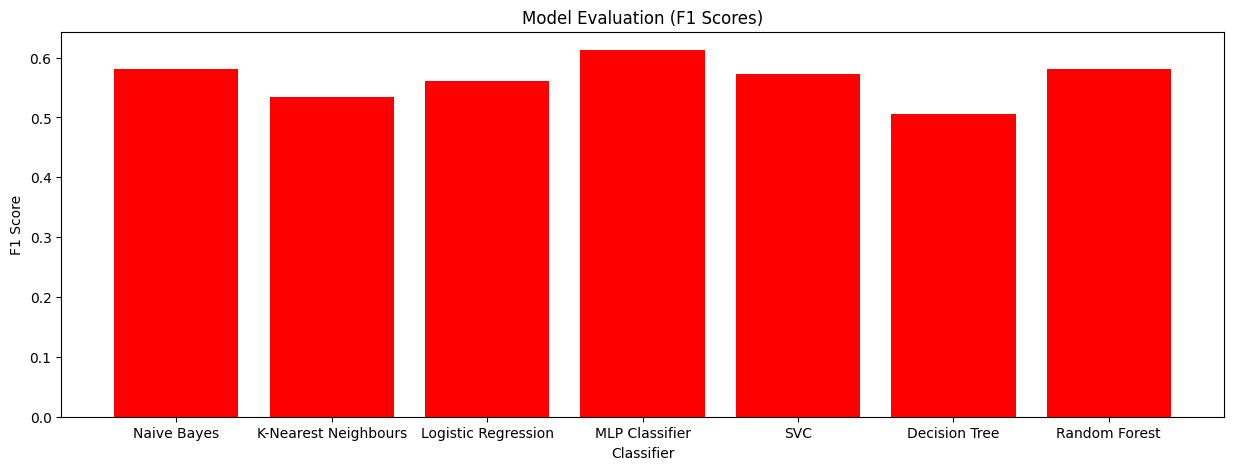

Model with the highest F1 score: MLP Classifier


In [17]:
plt.figure(figsize=(15, 5))
plt.bar(classifiers, f1_scr, color='red')
plt.xlabel("Classifier")
plt.ylabel("F1 Score")
plt.title("Model Evaluation (F1 Scores)")
plt.show()

print("Model with the highest F1 score:", classifiers[f1_scr.index(max(f1_scr))])

Παρατηρούμε πως το μοντέλο MLP έχει την καλύτερη επίδοση.

### 5. Προετοιμασία αρχείου για την πρώτη υποβολή στο kaggle

5.α. Χρησιμοποιήστε **ΜΟΝΟ** το μοντέλο σας με την καλύτερη επίδοση για να κάνετε προβλέψεις, χρησιμοποιώντας το [test set](https://drive.google.com/file/d/14HsEya9h1wxk2wJLh6c0Ibz2V4_WA13p/view?usp=sharing).


In [18]:
uploaded = files.upload()

dftest = pd.read_csv(next(iter(uploaded)))

Saving test.csv to test.csv


In [19]:
dftest['Pressure'] = dftest['Pressure9am'] + dftest['Pressure3pm']
dftest['WindSpeed'] = dftest['WindSpeed9am'] + dftest['WindSpeed3pm']
dftest['Temp'] = dftest['MaxTemp'] + dftest['Temp3pm']
dftest['Month'] = pd.DatetimeIndex(dftest['Date']).month

dftest['RainyWind'] = dftest.apply(lambda row: rain_by_wind9[row["WindDir9am"]] * rain_by_wind3[row["WindDir3pm"]] * rain_by_windg[row["WindGustDir"]], axis=1)
dftest['RainyCity'] = dftest.apply(lambda row: rain_by_city[row["Location"]], axis=1)

df3test = dftest.drop(['Date', 'Location', 'Evaporation', 'MinTemp', 'MaxTemp', 'Pressure9am', 'Pressure3pm',\
               'Temp9am', 'Temp3pm', 'WindDir3pm', 'WindDir9am', 'WindGustDir', 'WindSpeed9am', 'WindSpeed3pm'], axis=1)

result = model[3].predict(df3test)

df_result = pd.DataFrame()
df_result['ID'] = dftest['ID']
df_result['RainTomorrow'] = result
df_result = df_result.astype({'RainTomorrow':'int'})
df_result.head()

,ID,RainTomorrow
0,8790,1
1,2095,0
2,4316,0
3,6075,0
4,347,0


5.β. Αποθηκεύστε τις προβλέψεις από το καλύτερο μοντέλο σας σε ένα csv αρχείο. To csv αρχείο θα πρέπει να είναι περιέχει 2 στήλες: η πρώτη στήλη να περιέχει την στήλη id του test set file και η δεύτερη στήλη τις αντίστοιχες προβλέψεις που έκανε το καλύτερα εκπαιδευμένο μοντέλο σας (βήμα 5α).

In [20]:
df_result.to_csv('result1.csv', index = False)
files.download('result1.csv')

df_result.info()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2421 entries, 0 to 2420
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ID            2421 non-null   int64
 1   RainTomorrow  2421 non-null   int64
dtypes: int64(2)
memory usage: 38.0 KB


### 6. Βελτιστοποίηση μοντέλων με εύρεση καλύτερων υπερπαραμέτρων των ταξινομητών

6.α. Για τους 7 ταξινομητές βελτιστοποιήστε την επίδοσή τους χρησιμοποιώντας αναζήτηση πλέγματος με διασταυρούμενη επικύρωση (k-fold 5)  με σκοπό την εύρεση των βέλτιστων υπερπαραμέτρων.

In [21]:
from sklearn.model_selection import GridSearchCV

search_spaces = [
    # Naive Bayes
    {
        'var_smoothing': [1e-9, 1e-8, 1e-7], #προσθήκη μικρής θετικής τιμής στη διακύμανση, για αποφυγή αριθμητικών προβλημάτων λόγω πολύ μικρής διακύμανσης και ομαλοποίηση της πιθανότητας
    },
    # K-Nearest Neighbors
    {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'], #όλοι οι γείτονες έχουν ίση βαρύτητα ή βαρύτητα αντιστρόφως ανάλογη της απόστασης
    },
    # Logistic Regression
    {
        'penalty': ['l2'], #κανονικοποίηση τιμωρώντας μεγάλα βάρη
        'C': [0.1, 1, 10], #αντίστροφη δύναμη κανονικοποίησης
        'solver': ['liblinear'], #κατάλληλος για μικρά datasets
    },
    # MLP Classifier
    {
        'hidden_layer_sizes': [(50,), (100,)], #μέγεθος κρυφού επιπέδου
        'activation': ['relu'], #συνάρτηση ενεργοποίησης
        'learning_rate': ['constant', 'adaptive'], #σταθερό η μειούμενο αν η απόδοση σταματήσει να αυξάνεται
    },
    # SVC
    {
        'C': [0.1, 1, 10], #παράμετρος κανονικοποίησης που καθορίζει πόσο αυστηρά τιμωρούνται τα λάθη κατά την ταξινόμηση
        'kernel': ['linear', 'rbf'], #συνάρτηση πυρήνα
    },
    # Decision Tree
    {
        'criterion': ['gini', 'entropy'], #κριτήριο αξιολόγησης ποιότητας διάσπασης
        'max_depth': [None, 10, 20], #μέγιστο βάθος δέντρου
    },
    # Random Forest
    {
        'n_estimators': [50, 100, 200], #αριθμός δέντρων στο δάσος
        'criterion': ['gini', 'entropy'], #κριτήριο αξιολόγησης ποιότητας διάσπασης
    }
]

best_scores = {}
best_params = {}

for i in range(L):
    cl_name = classifiers[i]
    space = search_spaces[i]

    cli = classifier[i]
    modeli = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', cli)])

    grid = GridSearchCV(estimator=modeli, param_grid={'classifier__' + k: v for k, v in space.items()},
                        scoring='f1', cv=5, n_jobs=-1) #χρησιμοποιούμε k-fold 5 cross validation grid search για την εύρεση των βέλτιστων υπερπαραμέτρων
    grid.fit(X_train, y_train)

    best_scores[cl_name] = grid.best_score_
    best_params[cl_name] = grid.best_params_

    print(f"{cl_name} Best Params: {grid.best_params_} | Best F1 Score: {grid.best_score_}")


Naive Bayes Best Params: {'classifier__var_smoothing': 1e-09} | Best F1 Score: 0.5921004252457254


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


K-Nearest Neighbours Best Params: {'classifier__n_neighbors': 5, 'classifier__weights': 'distance'} | Best F1 Score: 0.5420704522348916
Logistic Regression Best Params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'} | Best F1 Score: 0.5916752304574765


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Classifier Best Params: {'classifier__activation': 'relu', 'classifier__hidden_layer_sizes': (100,), 'classifier__learning_rate': 'adaptive'} | Best F1 Score: 0.6190527617581812
SVC Best Params: {'classifier__C': 10, 'classifier__kernel': 'rbf'} | Best F1 Score: 0.5856333106817704
Decision Tree Best Params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10} | Best F1 Score: 0.5511891234782269
Random Forest Best Params: {'classifier__criterion': 'entropy', 'classifier__n_estimators': 200} | Best F1 Score: 0.6062201746002687


6.β. Εφαρμόστε στα εκπαιδευμένα μοντέλα από το validation set μόνο τα δείγματα χωρίς την ετικέτα τους (predict).


In [22]:
validation_predictions = {}

for i in range(L):
    cl_name = classifiers[i]

    best_model = GridSearchCV( #χρησιμοποιούμε μόνο τις καλύτερες παραμέτρους για τις προβλέψεις
        estimator=Pipeline(steps=[('preprocessor', preprocessor), ('classifier', classifier[i])]),
        param_grid={'classifier__' + k: v for k, v in search_spaces[i].items()},
        scoring='f1', cv=5, n_jobs=-1
    )
    best_model.fit(X_train, y_train)

    y_tst_pred = best_model.best_estimator_.predict(X_tst)
    validation_predictions[cl_name] = y_tst_pred
    print(f"{cl_name} validation predictions completed.")

Naive Bayes validation predictions completed.
K-Nearest Neighbours validation predictions completed.
Logistic Regression validation predictions completed.


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Classifier validation predictions completed.
SVC validation predictions completed.
Decision Tree validation predictions completed.
Random Forest validation predictions completed.



6.γ. Συγκρίνετε την έξοδο του κάθε μοντέλου σε σχέση με τις αντίστοιχες ετικέτες του validation set και αξιολογήστε την επιδοσή τους χρησιμοποιώντας το F1 score.


In [23]:
from sklearn.metrics import f1_score

f1_scores_validation = {}

for i in range(L):
    cl_name = classifiers[i]
    y_tst_pred = validation_predictions[cl_name]

    f1_tst_score = f1_score(y_tst, y_tst_pred)
    f1_scores_validation[cl_name] = f1_tst_score
    print(f"{cl_name} Validation F1 Score: {f1_tst_score}")

Naive Bayes Validation F1 Score: 0.5809617271835132
K-Nearest Neighbours Validation F1 Score: 0.5385556915544676
Logistic Regression Validation F1 Score: 0.5614457831325301
MLP Classifier Validation F1 Score: 0.6281179138321995
SVC Validation F1 Score: 0.5806451612903226
Decision Tree Validation F1 Score: 0.5440528634361234
Random Forest Validation F1 Score: 0.5850673194614443


6.δ.  Αξιολογήστε συνολικά την επίδοση των μοντέλων χρησιμοποιώντας κάποιο γράφημα (π.χ. ιστόγραμμα, bar plot) και σχολιάστε ποιο μοντέλο είχε την καλύτερη επίδοση.


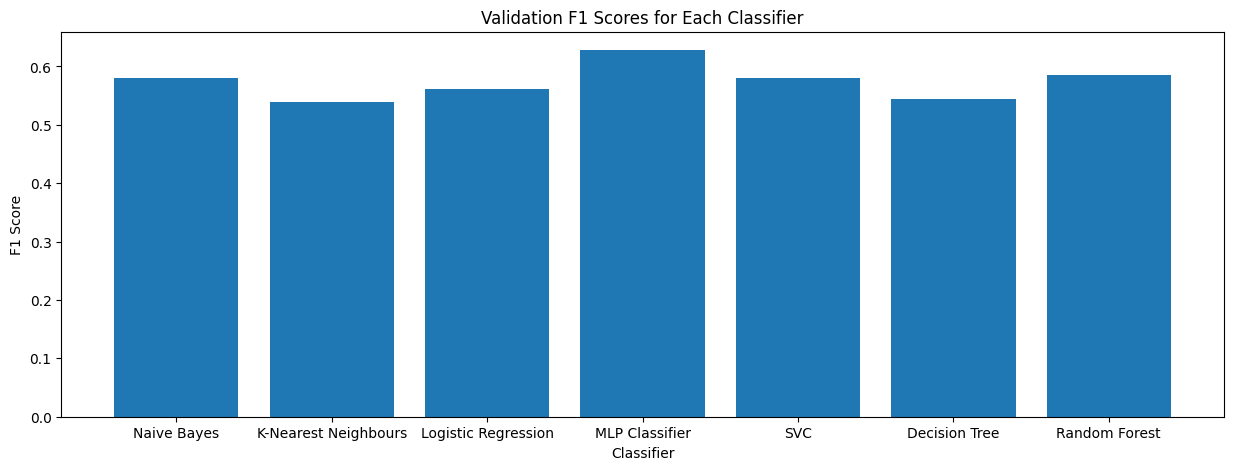

In [24]:
plt.figure(figsize=(15, 5))
plt.bar(f1_scores_validation.keys(), f1_scores_validation.values())
plt.xlabel("Classifier")
plt.ylabel("F1 Score")
plt.title("Validation F1 Scores for Each Classifier")
plt.show()

Παρατηρούμε πως και με τη βελτιστοποίηση το μοντέλο MLP έχει πάλι την καλύτερη επίδοση.

### 7. Προετοιμασία αρχείου για τη δεύτερη υποβολή στο kaggle

7.α. Χρησιμοποιήστε **ΜΟΝΟ** το μοντέλο σας με την καλύτερη επίδοση για να κάνετε προβλέψεις χρησιμοποιώντας το δοθέν σύνολο εκπαίδευσης (test set).


In [25]:
clf = MLPClassifier(hidden_layer_sizes = (250,), activation = 'logistic', solver = 'adam', learning_rate = 'adaptive')
modelf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
modelf.fit(X_train, y_train)
result = modelf.predict(df3test)

df_result = pd.DataFrame()
df_result['ID'] = dftest['ID']
df_result['RainTomorrow'] = result
df_result = df_result.astype({'RainTomorrow':'int'})

7.β. Αποθηκεύστε τις προβλέψεις από το καλύτερο μοντέλο σας σε ένα csv αρχείο. To csv αρχείο θα πρέπει να είναι περιέχει 2 στήλες: η πρώτη στήλη να περιέχει την στήλη id του test set file και η δεύτερη στήλη τις αντίστοιχες προβλέψεις που έκανε το καλύτερα εκπαιδευμένο μοντέλο σας (βήμα 7α).

In [26]:
df_result.to_csv('result2.csv', index = False)
files.download('result2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2421 entries, 0 to 2420
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ID            2421 non-null   int64
 1   RainTomorrow  2421 non-null   int64
dtypes: int64(2)
memory usage: 38.0 KB
